In [1]:
from src.models import run_random_forest
from src.evaluation import evaluate_regression, plot_all_models
from src.data_loader import download_sp500, load_data
from src.data_cleaning import clean_raw_data, save_cleaned_data
from src.feature_engineering import create_volatility_features, save_feature_engineering_csv
from src.models import split_data, run_random_forest
import logging
from src.logger import setup_logging
from src.config_loader import load_config
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)


config = load_config()

setup_logging()

logger = logging.getLogger(__name__)
logger.info("Logging works!")


from pathlib import Path
Path('reports').mkdir(exist_ok=True)

data = download_sp500()
df = load_data()

clean_df = clean_raw_data(df)
save_cleaned_data(clean_df)

feature_engineering_df = create_volatility_features(clean_df)

save_feature_engineering_csv(feature_engineering_df)

final_df = load_data(config['paths']['feature_engineering_path'])


X_train, X_test, y_train, y_test = split_data(final_df)

print(f"Train: {X_train.index[0].date()} to {X_train.index[-1].date()} ({len(X_train)} rows)")
print(f"Test:  {X_test.index[0].date()} to {X_test.index[-1].date()} ({len(X_test)} rows)")
print(f"Train y range: {y_train.min():.4f} to {y_train.max():.4f}")
print(f"Test y range:  {y_test.min():.4f} to {y_test.max():.4f}")

import numpy as np
from sklearn.metrics import mean_absolute_error
# In main.py, after split_data
rolling_baseline = y_train.rolling(21).mean().iloc[-1]  # last 21-day mean from train
baseline_pred_rolling = np.full(len(y_test), rolling_baseline)
print(f"Rolling baseline MAE: {mean_absolute_error(y_test, baseline_pred_rolling):.6f}")

model, y_pred = run_random_forest(X_train, X_test, y_train)

evaluate_regression(
    model,
    y_test,
    y_pred,
    model_name="Random Forest",
    X_train=X_train
)

from src.models import split_data, run_random_forest, run_xgboost, run_arima

# XGBoost — same split, same features
model_xgb, y_pred_xgb = run_xgboost(X_train, X_test, y_train, y_test)
evaluate_regression(model_xgb, y_test, y_pred_xgb, model_name="XGBoost", X_train=X_train)

# ARIMA — uses its own internal split, only needs the full df
model_arima, forecast_arima, arima_dates = run_arima(final_df)

len(y_test) == len(forecast_arima)

# Random Forest / XGBoost
# plot_predictions(
#     y_true=y_test.values,
#     y_pred=y_pred,
#     model_name="Random Forest",
#     dates=y_test.index
# )

# model_arima, forecast_arima, arima_dates = run_arima(final_df)
# plot_predictions(
#     y_true=final_df['y'].iloc[int(len(final_df)*0.8):].values,
#     y_pred=forecast_arima.values,
#     model_name="ARIMA",
#     dates=arima_dates
# )



2026-03-16 15:22:35,610 - __main__ - INFO - Logging works!
2026-03-16 15:22:35,613 - src.data_loader - INFO - Downloading S&P 500 data from 2000-01-01


[*********************100%***********************]  1 of 1 completed

2026-03-16 15:22:42,295 - src.data_loader - INFO - Saving data to C:\Users\Asus\Desktop\s&p500\data\raw\sp500.csv
2026-03-16 15:22:42,296 - src.data_loader - INFO - Data columns: ['Close', 'High', 'Low', 'Open', 'Volume']
2026-03-16 15:22:42,342 - src.data_loader - INFO - Loading 
2026-03-16 15:22:42,345 - src.data_loader - INFO - Loading data from C:\Users\Asus\Desktop\s&p500\data\raw\sp500.csv
2026-03-16 15:22:42,380 - src.data_cleaning - INFO - Cleaned data: (6588, 5)
2026-03-16 15:22:42,430 - src.data_cleaning - INFO - Saved cleaned data to data/processed/sp500_cleaned.csv
2026-03-16 15:22:42,430 - src.feature_engineering - INFO - Creating new features!
2026-03-16 15:22:42,442 - src.feature_engineering - INFO - Features created successfully!


2026-03-16 15:22:42,708 - src.feature_engineering - INFO - Saved cleaned data to data/processed/feature_engineering.csv
2026-03-16 15:22:42,708 - src.data_loader - INFO - Loading 
2026-03-16 15:22:42,708 - src.data_loader - INFO - Loading data from data/processed/feature_engineering.csv
Train: 2001-02-14 to 2021-01-28 (5020 rows)
Test:  2021-01-29 to 2026-01-29 (1256 rows)
Train y range: 0.0022 to 0.0541
Test y range:  0.0042 to 0.0267
Rolling baseline MAE: 0.003450
2026-03-16 15:22:47,308 - src.evaluation - INFO - Random Forest MAE: 0.007315
2026-03-16 15:22:47,308 - src.evaluation - INFO - Random Forest RMSE: 0.008712
2026-03-16 15:22:47,308 - src.evaluation - INFO - Random Forest R2: -3.0628
2026-03-16 15:22:47,308 - src.evaluation - INFO - Random Forest Directional Accuracy: 0.494
2026-03-16 15:22:47,361 - src.evaluation - INFO - Random Forest Top Features:
vol_lag_1       0.288289
range           0.147066
dist_ma30       0.090370
vol_lag_5       0.073387
mean_30         0.059820
r

c:\Users\Asus\Desktop\s&p500\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


2026-03-16 15:23:24,930 - src.models - INFO -   Rolling forecast: 300/1256 steps done
2026-03-16 15:23:41,439 - src.models - INFO -   Rolling forecast: 400/1256 steps done
2026-03-16 15:23:50,721 - src.models - INFO -   Rolling forecast: 500/1256 steps done
2026-03-16 15:23:59,970 - src.models - INFO -   Rolling forecast: 600/1256 steps done
2026-03-16 15:24:10,235 - src.models - INFO -   Rolling forecast: 700/1256 steps done
2026-03-16 15:24:17,703 - src.models - INFO -   Rolling forecast: 800/1256 steps done
2026-03-16 15:24:30,353 - src.models - INFO -   Rolling forecast: 900/1256 steps done
2026-03-16 15:24:41,918 - src.models - INFO -   Rolling forecast: 1000/1256 steps done
2026-03-16 15:24:57,900 - src.models - INFO -   Rolling forecast: 1100/1256 steps done
2026-03-16 15:25:09,051 - src.models - INFO -   Rolling forecast: 1200/1256 steps done
2026-03-16 15:25:14,604 - src.models - INFO - ARIMA Rolling Forecast MAE: 0.000284


True

Lengths match: True


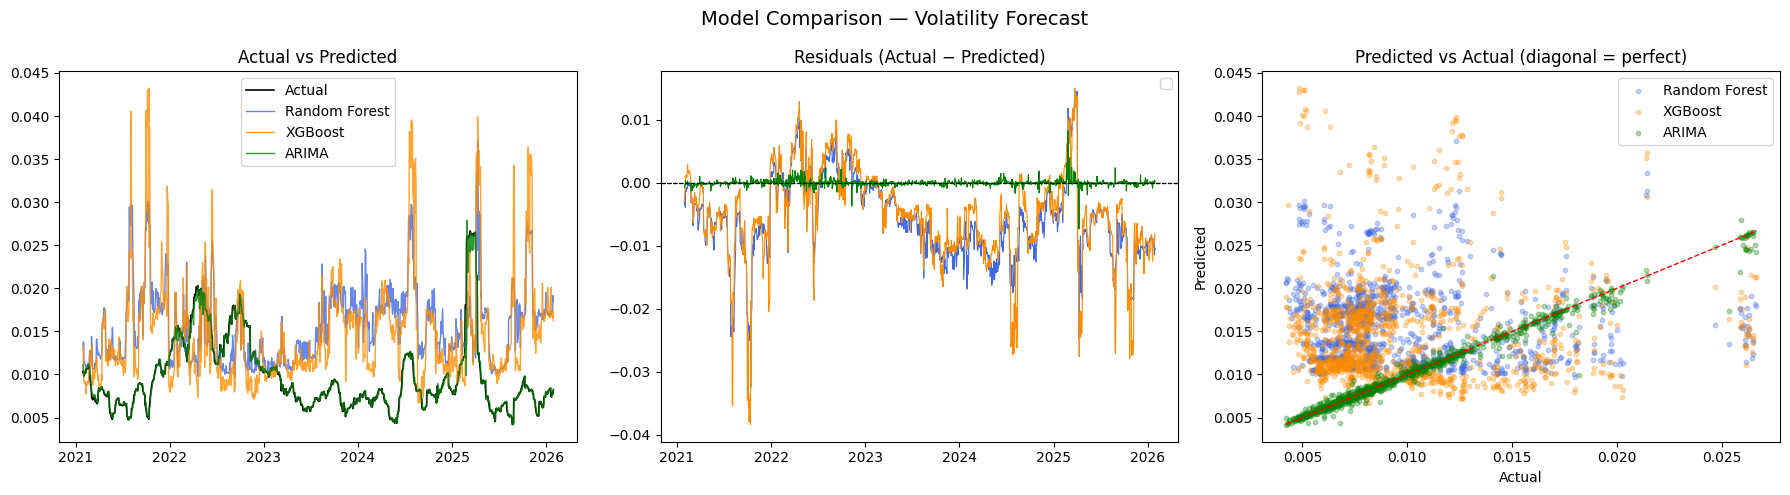

In [3]:
print(f"Lengths match: {len(y_test) == len(forecast_arima)}")

predictions = {
    "Random Forest": y_pred,
    "XGBoost": y_pred_xgb,
    "ARIMA": forecast_arima.values
}

plot_all_models(
    y_true=y_test.values,
    predictions=predictions,
    dates=y_test.index
)